In [39]:
suppressPackageStartupMessages({
    library(data.table)
    library(dplyr)
    library(SingleCellExperiment)
    library(parallel)
})

here::i_am("rna/gene_correlations.ipynb")
source(here::here('settings.R'))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code



In [40]:
#io = list()
io$metacells_sce = "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/rna/metacells/all_cells/SingleCellExperiment_metacells.rds"
io$metacells_meta = "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/rna/metacells/all_cells/metacells_metadata.txt.gz"

#outdir
io$outdir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/gene_correlations/'
dir.create(io$outdir, recursive=T, showWarning=F)

args = list()
args$celltypes = c("Epiblast",
                    "Primitive_Streak" ,
                    "Nascent_mesoderm",
                    "ExE_mesoderm",
                    "Mixed_mesoderm",
                    "Allantois",
                    "Mesenchyme",
                    "Haematoendothelial_progenitors",
                    "Endothelium",
                    "Blood_progenitors_1",
                    "Blood_progenitors_2",
                    "Erythroid1",
                    "Erythroid2",
                    "Erythroid3")

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Mmusculus_genes_BioMart.87.txt"

In [7]:
sce = readRDS(io$metacells_sce)
sce_filt = sce[,sce$celltype %in% args$celltypes]
sce_filt

class: SingleCellExperiment 
dim: 32285 908 
metadata(2): agg_pars n_cells
assays(2): counts logcounts
rownames(32285): Xkr4 Gm1992 ... AC234645.1 AC149090.1
rowData names(0):
colnames(908): E7.5_rep1#AAACGTACAAACCTTG-1
  E7.5_rep1#AAAGCAAGTCGAAGTC-1 ... E8.75_rep2#TTTACGAAGGATCCGC-1
  E8.75_rep2#TTTCTTGCAGCAGGTA-1
colData names(7): sample stage ... ncells nFeature_RNA
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [11]:
counts = logcounts(sce_filt)

In [9]:
biomart = fread(io$gene_metadata)

In [32]:
chr1 = biomart[chr=='chr1' & symbol %in% rownames(counts)]
head(chr1)

chr,start,end,strand,ens_id,description,symbol
<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
chr1,3205901,3671498,-,ENSMUSG00000051951,X-linked Kx blood group related 4 [Source:MGI Symbol;Acc:MGI:3528744],Xkr4
chr1,3466587,3513553,+,ENSMUSG00000089699,predicted gene 1992 [Source:MGI Symbol;Acc:MGI:3780162],Gm1992
chr1,3647309,3658904,-,ENSMUSG00000102331,"predicted gene, 19938 [Source:MGI Symbol;Acc:MGI:5012123]",Gm19938
chr1,3905739,3986215,-,ENSMUSG00000102343,"predicted gene, 37381 [Source:MGI Symbol;Acc:MGI:5610609]",Gm37381
chr1,3999557,4409241,-,ENSMUSG00000025900,retinitis pigmentosa 1 (human) [Source:MGI Symbol;Acc:MGI:1341105],Rp1
chr1,4490931,4497354,-,ENSMUSG00000025902,SRY (sex determining region Y)-box 17 [Source:MGI Symbol;Acc:MGI:107543],Sox17


In [34]:
which(chr1$symbol == 'Rp1')

[1] 5

In [37]:
corr_genes = function(gene1, gene2, method = 'spearman'){
    corr = data.table(gene1 = gene1, 
                      gene2 = gene2, 
                      corr = cor(counts[gene1,], counts[gene2,], method = method))
    return(corr)
}

In [45]:
# first gene
gene = 'Xkr4'
# select all genes downstream
genes = chr1[which(chr1$symbol == gene):nrow(chr1), ] %>% # select only downstream genes
    .[,gene_start := ifelse(strand=='+', start, end)]

# correlate
correlations = mclapply(genes$symbol, corr_genes, gene2=gene, mc.cores=20) %>% 
    rbindlist() %>%
    .[,distance := genes$gene_start-genes[1,gene_start]] # add distance



Warning message:
“Removed 135 rows containing missing values (`geom_point()`).”


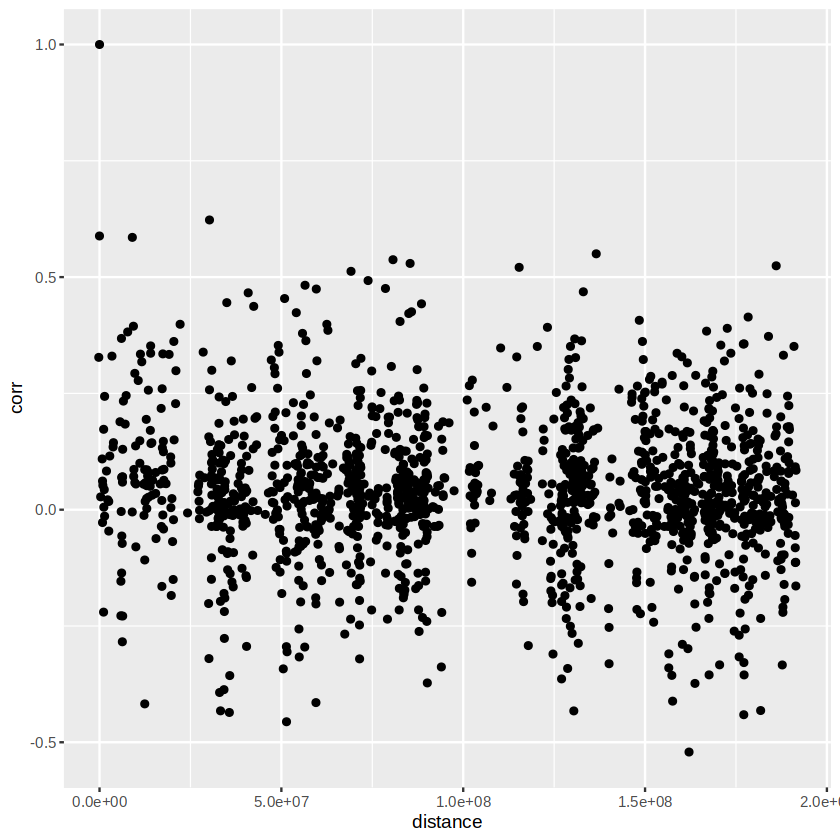

In [50]:
ggplot(correlations, aes(distance, corr)) + 
    geom_point()

In [230]:
chr1 = chr1 %>% # select only downstream genes
        .[,gene_start := ifelse(strand=='+', start, end)] %>%
        .[order(gene_start)]
all_genes = chr1$symbol

all_correlations = mclapply(all_genes, function(gene){
    # select all genes downstream
    genes = chr1[which(chr1$symbol == gene):nrow(chr1), ] # select only downstream genes

    # correlate
    correlations = mclapply(genes$symbol, corr_genes, gene2=gene, mc.cores=1) %>% 
        rbindlist() %>%
        .[,`:=`(gene1_pos = genes$gene_start,
                gene2_pos = genes[1,gene_start])] %>%
        .[,distance := gene1_pos-gene2_pos] # add distance
    return(correlations)
}, mc.cores=20)


In [231]:
test = rbindlist(all_correlations) %>%
    .[!is.na(corr)]

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


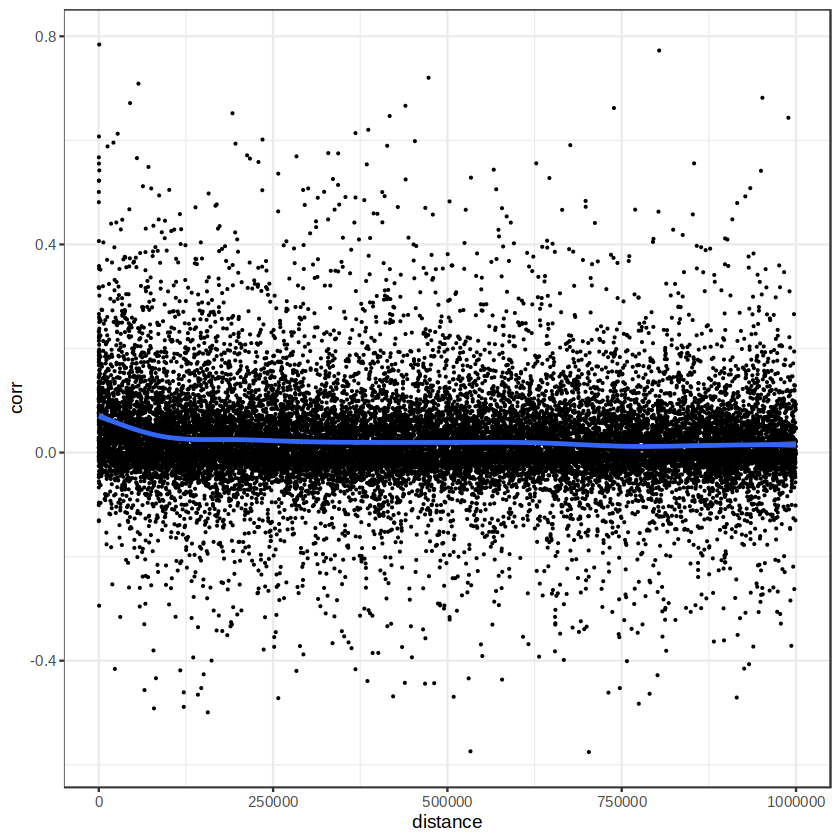

In [232]:
ggplot(test[distance<=1e6 & distance>0], aes(distance, corr)) + 
    geom_point(size=0.1) + 
    geom_smooth() + 
    theme_bw() 

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


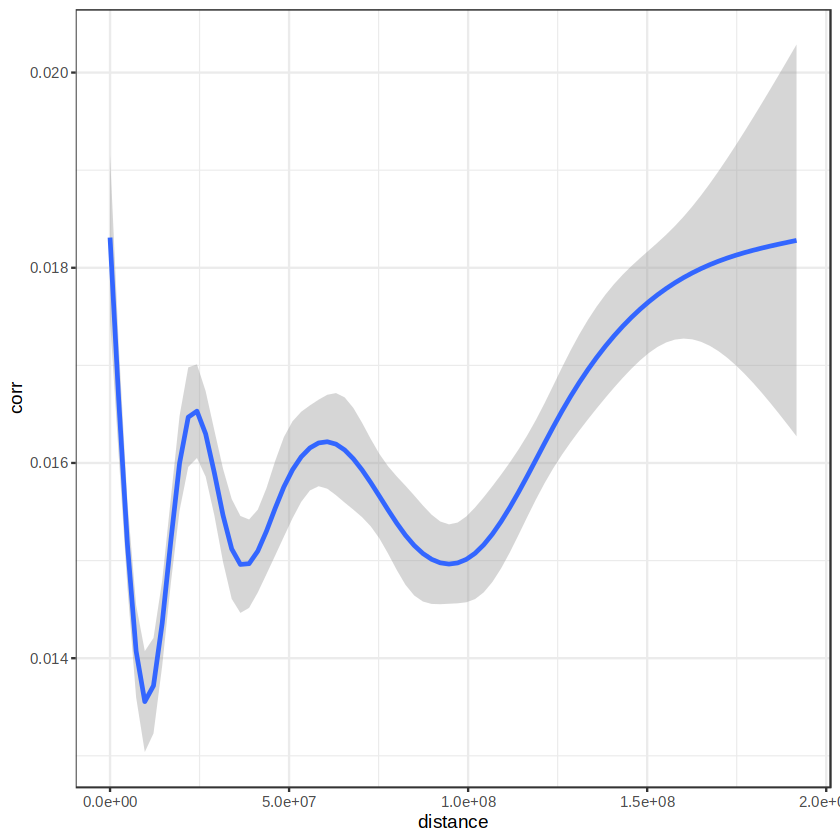

In [244]:
ggplot(test[distance>0], aes(distance, corr)) + 
    geom_smooth() + 
    theme_bw() 

In [245]:
test = test[order(abs(corr))]

In [246]:
hiC = test[, `:=`(mid_pos = gene2_pos+distance/2, 
                  height = distance/2)]

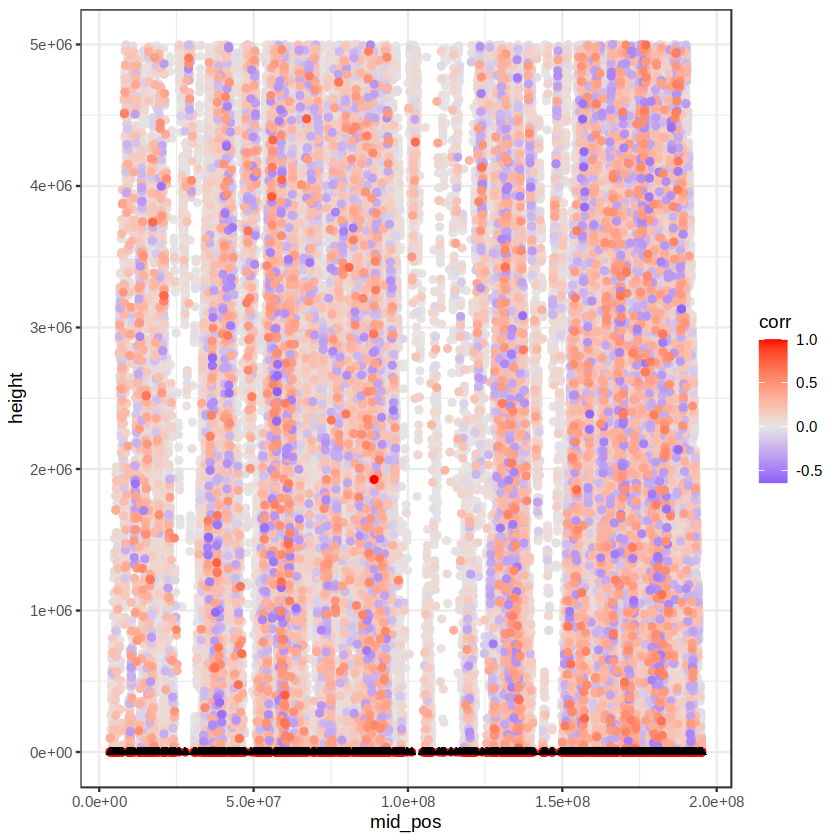

In [235]:
ggplot(hiC[height<5e6], aes(mid_pos, height, col=corr)) + 
    geom_point() +
    geom_point(data=hiC[height<5e6], aes(gene1_pos, 0), shape=17, col='black') +
    scale_color_gradient2(low='blue', mid='grey90', high='red') + 
    theme_bw()

In [247]:
hiC$h = 10000

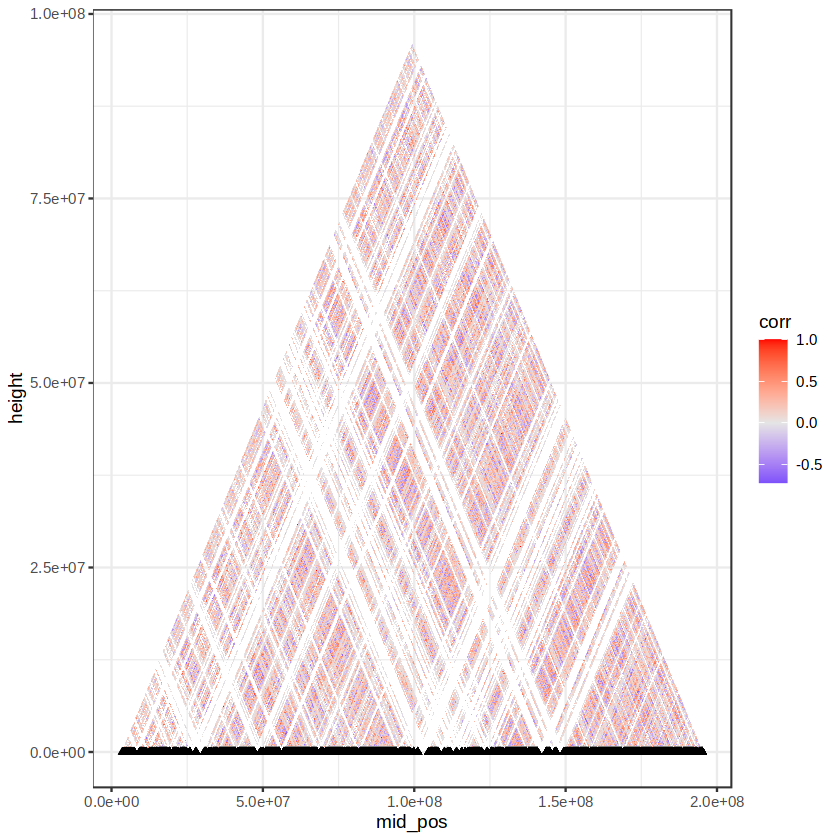

In [248]:
ggplot(hiC[distance>0], aes(mid_pos, height, fill=corr)) + 
    geom_tile(aes(height=h, width=h)) +
    geom_point(data=hiC[height<5e6], aes(gene1_pos, 0), shape=17, col='black') +
    scale_fill_gradient2(low='blue', mid='grey90', high='red') + 
    theme_bw()

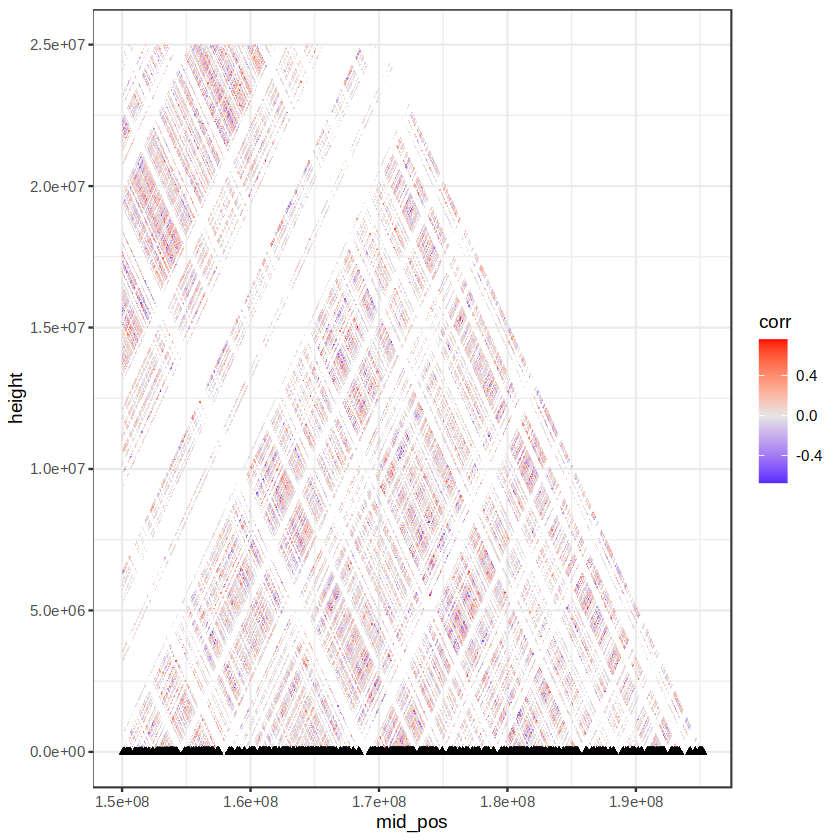

In [255]:
hiC_filt = hiC[distance>0 & mid_pos>1.5e8 & height<=2.5e7]
ggplot(hiC_filt, aes(mid_pos, height, fill=corr)) + 
    geom_tile(aes(height=h, width=h)) +
    geom_point(data=hiC_filt, aes(gene1_pos, 0), shape=17, col='black') +
    scale_fill_gradient2(low='blue', mid='grey90', high='red') + 
    theme_bw()

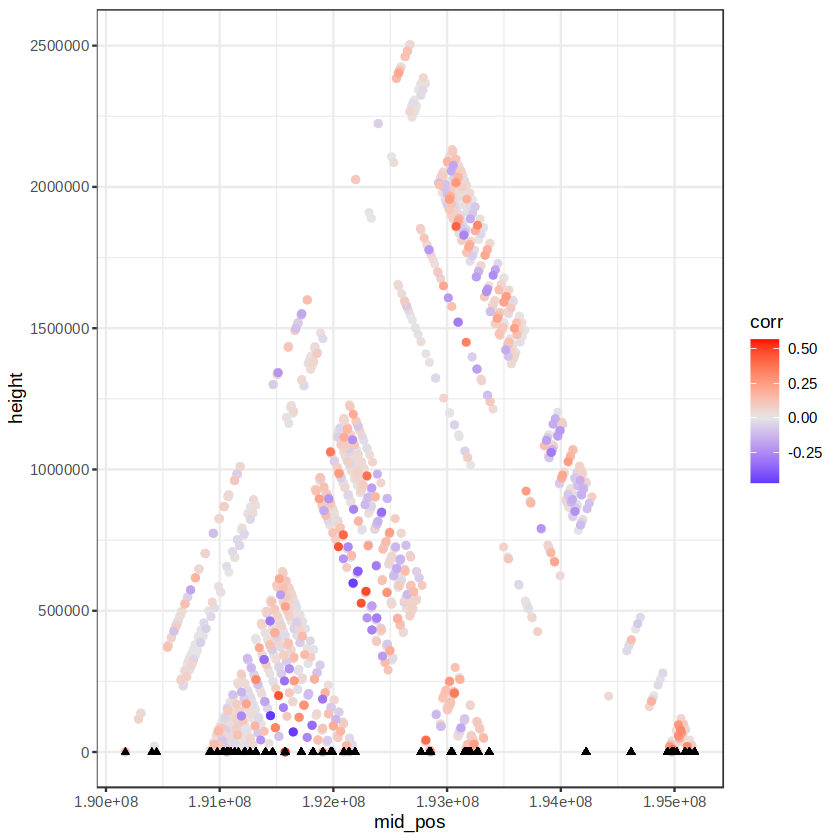

In [277]:
min = 1.8e8
hiC_filt = hiC[distance>0 & mid_pos >= 1.9e8 & gene1_pos >= 1.9e8 & gene2_pos >= 1.9e8]
ggplot(hiC_filt, aes(mid_pos, height, col=corr)) + 
    geom_point() +
    geom_point(data=hiC_filt, aes(gene1_pos, 0), shape=17, col='black') +
    scale_color_gradient2(low='blue', mid='grey90', high='red') + 
    theme_bw()

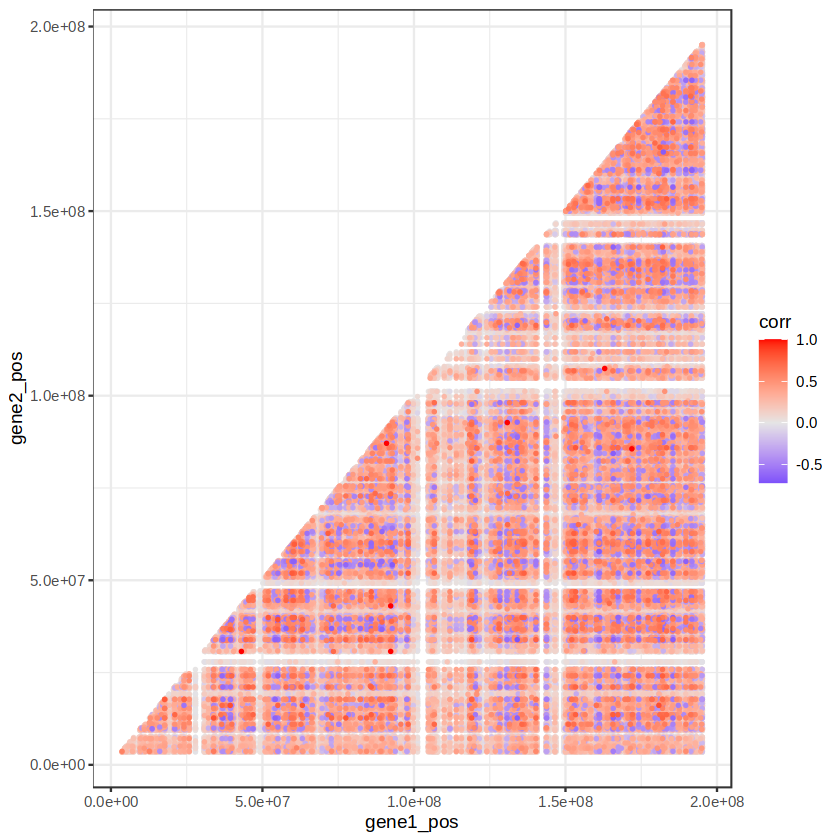

In [260]:
ggplot(test[distance>0], aes(gene1_pos, gene2_pos, col=corr)) + 
    geom_point(size=0.5) + 
    scale_color_gradient2(low='blue', mid='grey90', high='red') + 
    theme_bw()

In [264]:
shortest_dist = hiC[distance>0][,min:=min(distance), by=gene1] %>%
    unique(by='gene1')

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


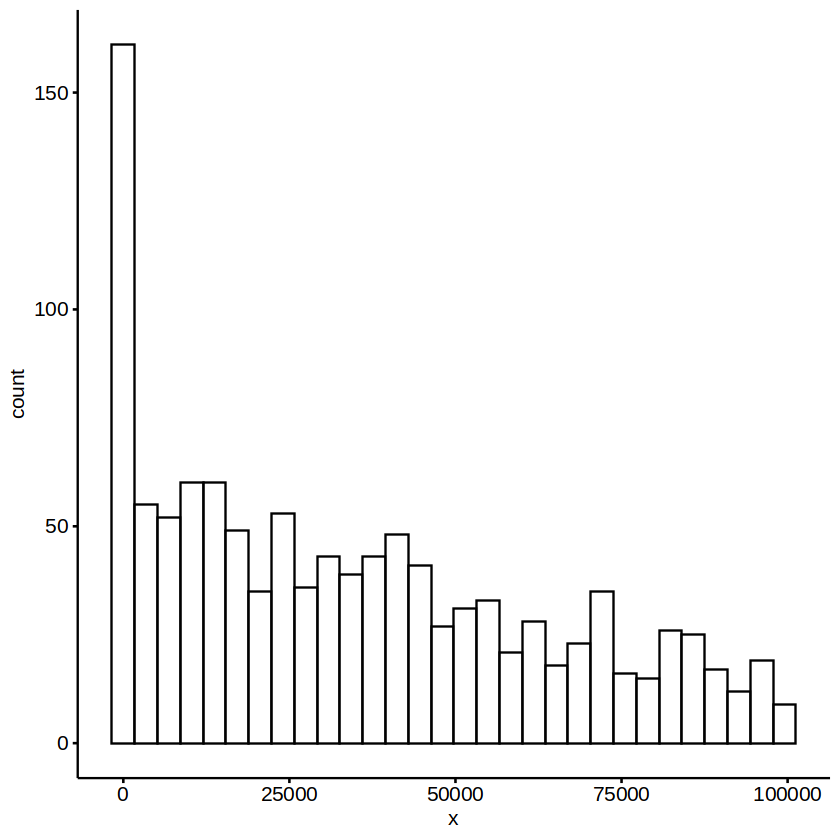

In [267]:
gghistogram(shortest_dist[min<1e5]$min)

In [259]:
head(hiC)

gene1,gene2,corr,gene1_pos,gene2_pos,distance,mid_pos,height,h
<chr>,<chr>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
Opn3,Gm28323,-2.911118e-07,175692776,51879608,123813168,113786192,61906584,10000
9630028B13Rik,Gm28320,-3.074558e-07,185441819,51148309,134293510,118295064,67146755,10000
Gm28342,Zfp451,3.466134e-07,89358144,33814595,55543549,61586370,27771774,10000
Mrps9,Coa5,3.887698e-07,42851233,37430103,5421130,40140668,2710565,10000
Nsl1,Cfhr2,-5.240434e-07,191063012,139858702,51204310,165460857,25602155,10000
Fam174a,Acadl,5.306957e-07,95313623,66863277,28450346,81088450,14225173,10000


In [48]:
nrow(correlations)

[1] 1736

In [46]:
head(correlations)

gene1,gene2,corr,distance
<chr>,<chr>,<dbl>,<int>
Xkr4,Xkr4,1.00000000,0
Gm1992,Xkr4,0.32746075,-204911
Gm19938,Xkr4,0.58837769,-12594
Gm37381,Xkr4,0.02757158,314717
Rp1,Xkr4,0.10908338,737743
Sox17,Xkr4,0.06150236,825856


In [31]:
corr_genes('Xkr4', 'Gm1992')

gene1,gene2,corr
<chr>,<chr>,<dbl>
Xkr4,Gm1992,0.3274608


In [10]:
head(biomart)

chr,start,end,strand,ens_id,description,symbol
<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
chr1,3073253,3074322,+,ENSMUSG00000102693,RIKEN cDNA 4933401J01 gene [Source:MGI Symbol;Acc:MGI:1918292],4933401J01Rik
chr1,3102016,3102125,+,ENSMUSG00000064842,"predicted gene, 26206 [Source:MGI Symbol;Acc:MGI:5455983]",Gm26206
chr1,3205901,3671498,-,ENSMUSG00000051951,X-linked Kx blood group related 4 [Source:MGI Symbol;Acc:MGI:3528744],Xkr4
chr1,3252757,3253236,+,ENSMUSG00000102851,"predicted gene, 18956 [Source:MGI Symbol;Acc:MGI:5011141]",Gm18956
chr1,3365731,3368549,-,ENSMUSG00000103377,"predicted gene, 37180 [Source:MGI Symbol;Acc:MGI:5610408]",Gm37180
chr1,3375556,3377788,-,ENSMUSG00000104017,"predicted gene, 37363 [Source:MGI Symbol;Acc:MGI:5610591]",Gm37363
